# Lecture 05 — Instance-based & Generative Classifiers: k-NN and Naive Bayes

**Learning objectives**

- Understand the $k$-nearest-neighbour rule, its distance metrics, and its bias–variance behaviour as a function of $k$.
- Implement a fully vectorized $k$-NN classifier from scratch and match scikit-learn.
- See the **curse of dimensionality** numerically: distance concentration and the growth of neighbourhoods.
- Know the complexity of brute-force search vs space-partitioning trees (KD-trees, ball trees).
- Define the **Bayes optimal classifier** and Bayes error, and relate $k$-NN to it (Cover–Hart bound).
- Contrast **generative** and **discriminative** classifiers.
- Derive and implement **Gaussian naive Bayes** and **multinomial naive Bayes** with Laplace smoothing.
- Derive **LDA** and **QDA** as Gaussian generative classifiers, implement them, and visualize their boundaries.

**Prerequisites**: `03_logistic_regression_and_classification.ipynb` (probabilistic classification, metrics), `04_model_evaluation_and_selection.ipynb` (cross-validation, pipelines). Multivariate Gaussians and Bayes' rule.

**Contents**

1. The $k$-nearest-neighbour rule
2. Distance metrics and feature scaling
3. Vectorized $k$-NN from scratch
4. Choosing $k$: decision boundaries and cross-validation
5. The curse of dimensionality
6. Fast neighbour search: KD-trees and complexity
7. The Bayes optimal classifier
8. Generative vs discriminative classifiers
9. Gaussian naive Bayes
10. Multinomial naive Bayes for text
11. LDA and QDA
12. Pitfalls & practical tips
13. Exercises
14. Summary & further reading

In [1]:
%matplotlib inline
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import logsumexp
from sklearn.datasets import load_iris, load_wine, load_digits, load_breast_cancer, make_moons, make_classification
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.base import BaseEstimator, ClassifierMixin

np.random.seed(42)
rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (7, 4.5)
np.set_printoptions(precision=4, suppress=True)

## 1. The $k$-nearest-neighbour rule

$k$-NN is the prototypical **instance-based** (memory-based, non-parametric, "lazy") learner: training = storing the data. To classify a query $\mathbf{x}$:

1. find the set $N_k(\mathbf{x})$ of the $k$ training points closest to $\mathbf{x}$ under a distance $d$;
2. predict the majority label: $\hat y(\mathbf{x}) = \arg\max_c \sum_{i\in N_k(\mathbf{x})} \mathbb{1}\{y_i = c\}$.

The vote fractions are a local estimate of the posterior,

$$
\hat p(y=c\mid\mathbf{x}) = \frac{1}{k}\sum_{i\in N_k(\mathbf{x})}\mathbb{1}\{y_i=c\},
$$

which can be read as a density estimate: if a ball of volume $V$ around $\mathbf{x}$ contains $k$ points, $k_c$ of class $c$, then $\hat p(\mathbf{x}\mid c) = \frac{k_c}{n_c V}$, $\hat p(c) = \frac{n_c}{n}$, and Bayes' rule gives $\hat p(c\mid\mathbf{x}) = k_c / k$ (Bishop §2.5.2).

**Variants**: distance-weighted votes ($w_i \propto 1/d(\mathbf{x},\mathbf{x}_i)$), $k$-NN regression (average of neighbours' targets), radius neighbours.

**Bias–variance**: $k=1$ has zero training error and very high variance (a jagged boundary that follows noise); large $k$ averages over big neighbourhoods — low variance, high bias; $k=n$ predicts the majority class everywhere. The **effective number of parameters** is roughly $n/k$ (ESL §2.3.2).

**Consistency**: if $k\to\infty$ and $k/n\to 0$, the $k$-NN error converges to the Bayes error (Stone, 1977). For $k=1$ and $n\to\infty$, Cover & Hart (1967) proved $R^* \le R_{1\text{NN}} \le 2R^*(1-R^*)$ (binary case): the 1-NN rule is at most twice as bad as the best possible classifier.

## 2. Distance metrics and feature scaling

Common choices for $\mathbf{x}, \mathbf{z}\in\mathbb{R}^d$:

- **Minkowski** $L_p$: $d_p(\mathbf{x},\mathbf{z}) = \big(\sum_j |x_j - z_j|^p\big)^{1/p}$ — Euclidean ($p=2$), Manhattan ($p=1$), Chebyshev ($p=\infty$, $\max_j|x_j-z_j|$).
- **Mahalanobis**: $d_M(\mathbf{x},\mathbf{z}) = \sqrt{(\mathbf{x}-\mathbf{z})^\top M(\mathbf{x}-\mathbf{z})}$, $M\succ 0$; with $M=\Sigma^{-1}$ it whitens correlated features. *Metric learning* (e.g. LMNN, NCA) learns $M$.
- **Cosine distance** $1 - \frac{\mathbf{x}^\top\mathbf{z}}{\|\mathbf{x}\|\|\mathbf{z}\|}$ for text / embeddings, **Hamming** for binary strings.

**Scaling matters**: Euclidean distance is dominated by the features with the largest numerical range. A feature measured in millimetres instead of metres gets $10^6$ times the weight in $d_2^2$. Standardize (or otherwise normalize) features, inside a `Pipeline` (Lecture 04).

**Vectorizing Euclidean distances.** For query matrix $Q\in\mathbb{R}^{m\times d}$ and data $X\in\mathbb{R}^{n\times d}$,

$$
\|\mathbf{q}_a - \mathbf{x}_b\|^2 = \|\mathbf{q}_a\|^2 + \|\mathbf{x}_b\|^2 - 2\,\mathbf{q}_a^\top\mathbf{x}_b
\quad\Longrightarrow\quad
D^2 = \mathbf{s}_Q\mathbf{1}^\top + \mathbf{1}\mathbf{s}_X^\top - 2QX^\top ,
$$

a single matrix product ($O(mnd)$ flops, BLAS-fast). Clip tiny negatives caused by round-off before taking square roots.

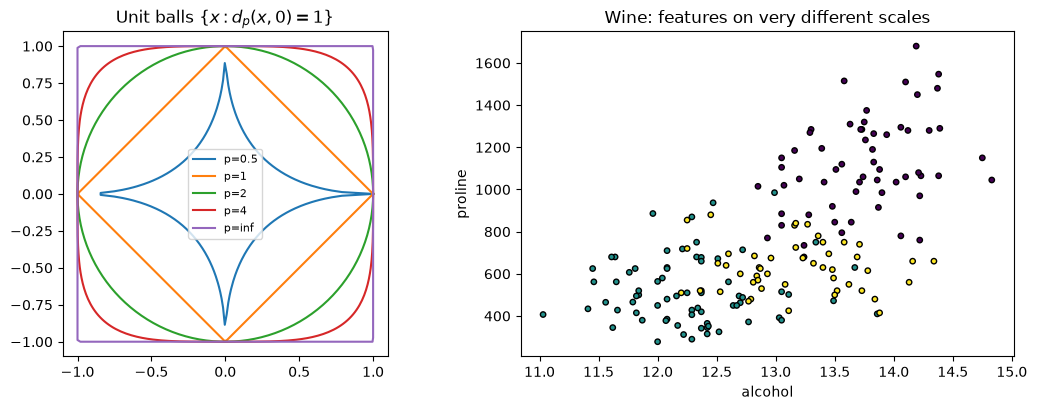

5-NN on wine, raw features: CV acc=0.663;  standardized: CV acc=0.961


In [2]:
# Unit balls of the Minkowski distances, and the effect of scaling on neighbours
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
th = np.linspace(0, 2 * np.pi, 400)
for p in [0.5, 1, 2, 4, np.inf]:
    u = np.c_[np.cos(th), np.sin(th)]
    norm = np.max(np.abs(u), 1) if p == np.inf else (np.abs(u) ** p).sum(1) ** (1 / p)
    ax[0].plot(u[:, 0] / norm, u[:, 1] / norm, label=f"p={p}")
ax[0].set_aspect("equal"); ax[0].legend(fontsize=8); ax[0].set_title(r"Unit balls $\{x: d_p(x,0)=1\}$")

wine = load_wine()
Xw = wine.data[:, [0, 12]]            # alcohol (~11-15) and proline (~300-1700)
cv = StratifiedKFold(5, shuffle=True, random_state=0)
raw = cross_val_score(KNeighborsClassifier(5), wine.data, wine.target, cv=cv).mean()
scaled = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(5)), wine.data, wine.target, cv=cv).mean()
ax[1].scatter(Xw[:, 0], Xw[:, 1], c=wine.target, cmap="viridis", s=15, edgecolor="k")
ax[1].set_xlabel("alcohol"); ax[1].set_ylabel("proline"); ax[1].set_title("Wine: features on very different scales")
plt.tight_layout(); plt.show()
print(f"5-NN on wine, raw features: CV acc={raw:.3f};  standardized: CV acc={scaled:.3f}")

## 3. Vectorized $k$-NN from scratch

Implementation plan (no Python loop over queries):

1. compute the $m\times n$ squared-distance matrix with the identity above;
2. use `np.argpartition` to get the $k$ smallest per row in $O(n)$ instead of a full $O(n\log n)$ sort;
3. gather neighbour labels, count votes with a one-hot sum, and take the argmax.

Ties in the vote are broken by the smallest class index here (sklearn does the same). Process queries in **chunks** to bound memory ($m\times n$ floats).

In [3]:
def pairwise_sq_dists(Q, X):
    # ||q||^2 + ||x||^2 - 2 q.x, computed for all pairs at once; clip round-off negatives.
    d2 = (Q ** 2).sum(1)[:, None] + (X ** 2).sum(1)[None, :] - 2.0 * Q @ X.T
    return np.maximum(d2, 0.0)

class KNNClassifierScratch:
    def __init__(self, k=5, weights="uniform", chunk=2048):
        self.k, self.weights, self.chunk = k, weights, chunk

    def fit(self, X, y):
        self.X = np.asarray(X, float)
        self.classes_, self.y_idx = np.unique(y, return_inverse=True)    # labels -> 0..C-1
        return self

    def kneighbors(self, Q):
        d2 = pairwise_sq_dists(Q, self.X)
        nn = np.argpartition(d2, self.k - 1, axis=1)[:, :self.k]        # k smallest, unordered
        dn = np.take_along_axis(d2, nn, axis=1)
        order = np.argsort(dn, axis=1)                                   # sort only the k candidates
        return np.sqrt(np.take_along_axis(dn, order, 1)), np.take_along_axis(nn, order, 1)

    def predict_proba(self, Q):
        Q = np.asarray(Q, float)
        out = []
        for s in range(0, len(Q), self.chunk):
            dist, nn = self.kneighbors(Q[s:s + self.chunk])
            w = np.ones_like(dist) if self.weights == "uniform" else 1.0 / np.maximum(dist, 1e-12)
            onehot = np.eye(len(self.classes_))[self.y_idx[nn]]          # (m, k, C)
            votes = (w[:, :, None] * onehot).sum(1)
            out.append(votes / votes.sum(1, keepdims=True))
        return np.vstack(out)

    def predict(self, Q):
        return self.classes_[np.argmax(self.predict_proba(Q), axis=1)]

digits = load_digits()
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(digits.data, digits.target, test_size=0.3,
                                              stratify=digits.target, random_state=0)
for k in [1, 5, 15]:
    ours = KNNClassifierScratch(k).fit(Xd_tr, yd_tr)
    sk = KNeighborsClassifier(n_neighbors=k, algorithm="brute").fit(Xd_tr, yd_tr)
    agree = np.mean(ours.predict(Xd_te) == sk.predict(Xd_te))
    print(f"k={k:2d}: scratch acc={np.mean(ours.predict(Xd_te) == yd_te):.4f}  "
          f"sklearn acc={sk.score(Xd_te, yd_te):.4f}  prediction agreement={agree:.4f}")

k= 1: scratch acc=0.9833  sklearn acc=0.9833  prediction agreement=1.0000


k= 5: scratch acc=0.9796  sklearn acc=0.9796  prediction agreement=1.0000


k=15: scratch acc=0.9741  sklearn acc=0.9741  prediction agreement=1.0000


In [4]:
# Loop vs vectorized timing (same result)
def knn_predict_loop(Xtr, ytr, Q, k):
    preds = []
    for q in Q:
        d = np.sqrt(((Xtr - q) ** 2).sum(1))
        nn = np.argsort(d)[:k]
        preds.append(np.bincount(ytr[nn], minlength=10).argmax())
    return np.array(preds)

t0 = time.perf_counter(); p_loop = knn_predict_loop(Xd_tr, yd_tr, Xd_te, 5); t_loop = time.perf_counter() - t0
t0 = time.perf_counter(); p_vec = KNNClassifierScratch(5).fit(Xd_tr, yd_tr).predict(Xd_te); t_vec = time.perf_counter() - t0
print(f"python loop: {t_loop*1e3:.1f} ms   vectorized: {t_vec*1e3:.1f} ms   same predictions: {np.mean(p_loop == p_vec):.4f}")

python loop: 137.8 ms   vectorized: 96.5 ms   same predictions: 1.0000


## 4. Choosing $k$: decision boundaries and cross-validation

On the two-moons data we visualize how $k$ trades variance for bias. Then we pick $k$ by cross-validation, plotting training and CV error against $1/k$ ("model complexity" grows to the right, as in ESL Fig. 2.4). A useful rule of thumb: prefer **odd** $k$ in binary problems to avoid ties, and a common starting point is $k\approx\sqrt{n}$ — but always validate.

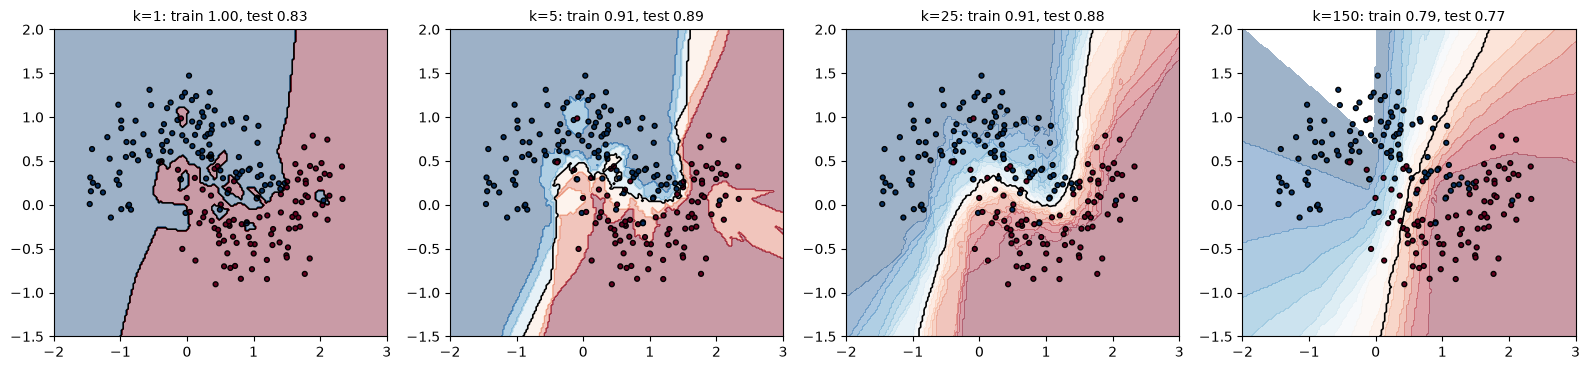

In [5]:
Xm, ym = make_moons(n_samples=400, noise=0.3, random_state=1)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.5, random_state=0)
x0, x1 = np.meshgrid(np.linspace(-2, 3, 200), np.linspace(-1.5, 2, 200))
grid = np.c_[x0.ravel(), x1.ravel()]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, k in zip(axes, [1, 5, 25, 150]):
    knn = KNNClassifierScratch(k).fit(Xm_tr, ym_tr)
    P = knn.predict_proba(grid)[:, 1].reshape(x0.shape)
    ax.contourf(x0, x1, P, levels=20, cmap="RdBu_r", alpha=0.4)
    ax.contour(x0, x1, P, levels=[0.5], colors="k", linewidths=1.2)
    ax.scatter(Xm_tr[:, 0], Xm_tr[:, 1], c=ym_tr, cmap="RdBu_r", s=12, edgecolor="k")
    tr_acc = np.mean(knn.predict(Xm_tr) == ym_tr); te_acc = np.mean(knn.predict(Xm_te) == ym_te)
    ax.set_title(f"k={k}: train {tr_acc:.2f}, test {te_acc:.2f}", fontsize=10)
plt.tight_layout(); plt.show()

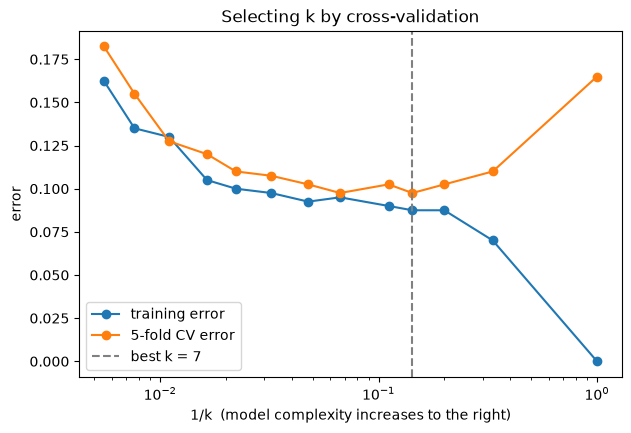

In [6]:
ks = np.array([1, 3, 5, 7, 9, 15, 21, 31, 45, 61, 91, 131, 181])
cv = StratifiedKFold(5, shuffle=True, random_state=0)
cv_err = [1 - cross_val_score(KNeighborsClassifier(k), Xm, ym, cv=cv).mean() for k in ks]
tr_err = [1 - KNeighborsClassifier(k).fit(Xm, ym).score(Xm, ym) for k in ks]
best_k = ks[int(np.argmin(cv_err))]
plt.semilogx(1 / ks, tr_err, "o-", label="training error")
plt.semilogx(1 / ks, cv_err, "o-", label="5-fold CV error")
plt.axvline(1 / best_k, ls="--", c="gray", label=f"best k = {best_k}")
plt.xlabel("1/k  (model complexity increases to the right)"); plt.ylabel("error"); plt.legend()
plt.title("Selecting k by cross-validation"); plt.show()

## 5. The curse of dimensionality

Local methods rely on the existence of *nearby* training points. In high dimensions this breaks down:

**Neighbourhoods are not local.** For $n$ points uniform in the unit cube $[0,1]^d$, a sub-cube capturing a fraction $r$ of the data has edge length $e_d(r) = r^{1/d}$. To capture 1% of the data in $d=10$ requires $e = 0.01^{1/10}\approx 0.63$ of the range of *each* coordinate — hardly "local".

**Distances concentrate.** For i.i.d. coordinates, $\|\mathbf{x}-\mathbf{z}\|^2 = \sum_j (x_j - z_j)^2$ is a sum of $d$ i.i.d. terms: its mean grows like $d$ but its standard deviation only like $\sqrt d$, so the **relative contrast**

$$
\frac{d_{\max} - d_{\min}}{d_{\min}} \xrightarrow{d\to\infty} 0
$$

(Beyer et al., 1999): the nearest and the farthest neighbour become almost equally far, and "nearest" loses meaning.

**Sample complexity.** To keep the same density of samples (e.g. a grid with spacing $h$), $n$ must grow like $h^{-d}$ — exponentially in $d$.

Real data often live near a **low-dimensional manifold** (digits: $d=64$ pixels but far fewer degrees of freedom), which is why $k$-NN still works on them; irrelevant noise features, however, hurt it badly.

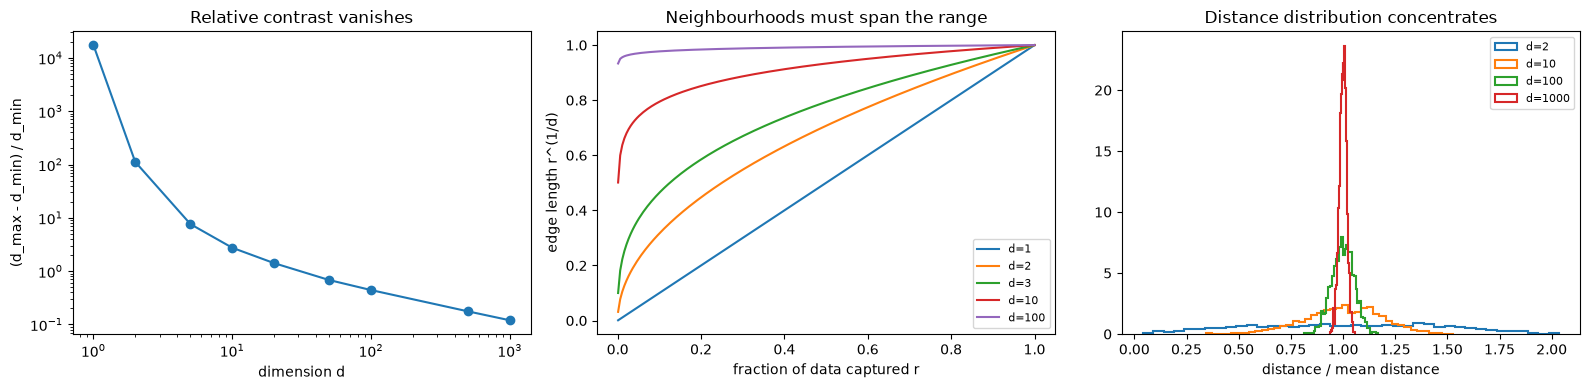

d=    1: relative contrast=17412.749   mean d_min/d_max=0.001
d=    2: relative contrast= 112.177   mean d_min/d_max=0.014
d=    5: relative contrast=   7.622   mean d_min/d_max=0.127
d=   10: relative contrast=   2.748   mean d_min/d_max=0.272
d=   20: relative contrast=   1.415   mean d_min/d_max=0.417
d=   50: relative contrast=   0.680   mean d_min/d_max=0.596
d=  100: relative contrast=   0.442   mean d_min/d_max=0.694
d=  500: relative contrast=   0.176   mean d_min/d_max=0.851
d= 1000: relative contrast=   0.120   mean d_min/d_max=0.893


In [7]:
dims = [1, 2, 5, 10, 20, 50, 100, 500, 1000]
contrast, ratio_mean = [], []
for d in dims:
    Xu = rng.random((1000, d)); q = rng.random((50, d))
    D = np.sqrt(pairwise_sq_dists(q, Xu))
    contrast.append(np.mean((D.max(1) - D.min(1)) / D.min(1)))
    ratio_mean.append(np.mean(D.min(1) / D.max(1)))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].loglog(dims, contrast, "o-"); ax[0].set_xlabel("dimension d"); ax[0].set_ylabel("(d_max - d_min) / d_min")
ax[0].set_title("Relative contrast vanishes")
r = np.linspace(0.001, 1, 200)
for d in [1, 2, 3, 10, 100]:
    ax[1].plot(r, r ** (1 / d), label=f"d={d}")
ax[1].set_xlabel("fraction of data captured r"); ax[1].set_ylabel("edge length r^(1/d)"); ax[1].legend(fontsize=8)
ax[1].set_title("Neighbourhoods must span the range")
for d in [2, 10, 100, 1000]:
    Xu = rng.random((2000, d)); q = rng.random((1, d))
    dd = np.sqrt(pairwise_sq_dists(q, Xu))[0]
    ax[2].hist(dd / dd.mean(), bins=40, histtype="step", lw=1.5, label=f"d={d}", density=True)
ax[2].set_xlabel("distance / mean distance"); ax[2].set_title("Distance distribution concentrates"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()
for d, c, m in zip(dims, contrast, ratio_mean):
    print(f"d={d:5d}: relative contrast={c:8.3f}   mean d_min/d_max={m:.3f}")

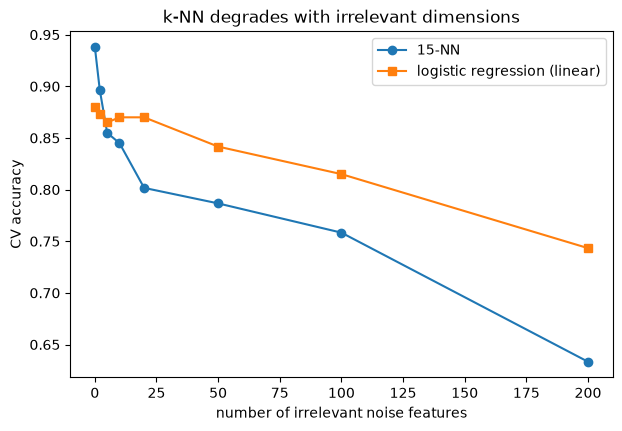

In [8]:
# Effect on accuracy: 2 informative dimensions + an increasing number of pure-noise dimensions
n_noise = [0, 2, 5, 10, 20, 50, 100, 200]
acc_knn, acc_lr = [], []
base_X, base_y = make_moons(n_samples=600, noise=0.25, random_state=0)
for m in n_noise:
    Xn = np.c_[base_X, rng.normal(0, 1, (600, m))]
    acc_knn.append(cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(15)), Xn, base_y, cv=5).mean())
    acc_lr.append(cross_val_score(make_pipeline(StandardScaler(), LogisticRegression()), Xn, base_y, cv=5).mean())
plt.plot(n_noise, acc_knn, "o-", label="15-NN")
plt.plot(n_noise, acc_lr, "s-", label="logistic regression (linear)")
plt.xlabel("number of irrelevant noise features"); plt.ylabel("CV accuracy"); plt.legend()
plt.title("k-NN degrades with irrelevant dimensions"); plt.show()

## 6. Fast neighbour search: KD-trees and complexity

**Brute force**: $O(nd)$ per query (plus $O(n)$ selection), no training cost; embarrassingly parallel and BLAS-friendly. Memory $O(nd)$ for storing the training set is unavoidable.

**KD-tree** (Bentley, 1975): recursively split the data along one coordinate at the median (cycling or choosing the widest dimension), producing a balanced binary tree of depth $O(\log n)$. Construction $O(n\log n)$ (with linear-time median finding; $O(dn\log n)$ overall with dimension choice). A query descends to the leaf containing $\mathbf{x}$, then **backtracks**, pruning any subtree whose bounding hyperrectangle is farther than the current $k$-th best distance.

- In low dimension the expected query cost is $O(\log n)$ (Friedman, Bentley & Finkel, 1977).
- The pruning test fails more and more as $d$ grows (distance concentration again!); a rule of thumb is that KD-trees help only when $n \gg 2^d$. For $d \gtrsim 20$ they typically degrade toward brute force, $O(nd)$.

**Ball trees** partition with hyperspheres and handle moderate dimensions and general metrics better. For very large, high-dimensional data one uses **approximate** nearest neighbours (locality-sensitive hashing, graph-based methods such as HNSW, product quantization).

Below we time sklearn's `brute` vs `kd_tree` for increasing $d$ at fixed $n$.

query time for 500 queries against 20,000 points (ms):
    brute  kd_tree
d                 
2   442.3      1.8
4   430.8     17.7
8   487.5     70.8
16  422.7    355.1
32  512.3    643.7
64  510.9   1400.0


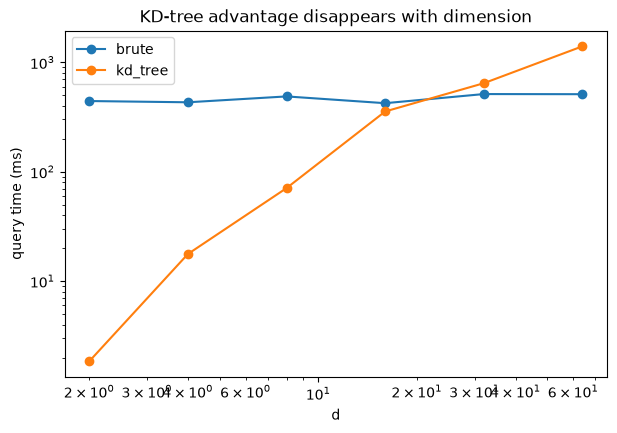

In [9]:
n_ref, n_q = 20000, 500
res = []
for d in [2, 4, 8, 16, 32, 64]:
    Xr = rng.random((n_ref, d)); Qr = rng.random((n_q, d))
    row = {"d": d}
    for algo in ["brute", "kd_tree"]:
        nnm = NearestNeighbors(n_neighbors=5, algorithm=algo).fit(Xr)
        t0 = time.perf_counter(); nnm.kneighbors(Qr); row[algo] = (time.perf_counter() - t0) * 1e3
    res.append(row)
tim = pd.DataFrame(res).set_index("d")
print("query time for 500 queries against 20,000 points (ms):")
print(tim.round(1).to_string())
tim.plot(marker="o", logy=True, logx=True)
plt.ylabel("query time (ms)"); plt.title("KD-tree advantage disappears with dimension"); plt.show()

In low dimension the KD-tree answers queries orders of magnitude faster than brute force; around $dpprox 16$ it loses its advantage and beyond that it is *slower*, because backtracking visits almost every leaf while paying tree-traversal overhead. scikit-learn's default `algorithm="auto"` uses such heuristics to pick brute force, KD-tree or ball tree.

## 7. The Bayes optimal classifier

Under 0–1 loss, the expected risk of a classifier $h$ is $R(h) = \mathbb{E}_{\mathbf{x}}\big[1 - p(y = h(\mathbf{x})\mid\mathbf{x})\big]$. It is minimized **pointwise** by

$$
h^*(\mathbf{x}) = \arg\max_c\ p(y=c\mid\mathbf{x}) = \arg\max_c\ p(\mathbf{x}\mid y=c)\,\pi_c ,
$$

the **Bayes classifier**, with **Bayes error** $R^* = \mathbb{E}_{\mathbf{x}}\big[1-\max_c p(c\mid\mathbf{x})\big]$ — the irreducible error due to overlapping classes. No classifier can beat $R^*$; it depends only on the data distribution.

We cannot compute $h^*$ in practice because $p(\mathbf{x}, y)$ is unknown — every classifier is an attempt to approximate it. On synthetic data where we *know* the class-conditional densities, we can compute $R^*$ by Monte Carlo and compare with $k$-NN as $n$ grows.

Bayes error R* (Monte Carlo) = 0.1639;  Cover-Hart bound 2R*(1-R*) = 0.2740


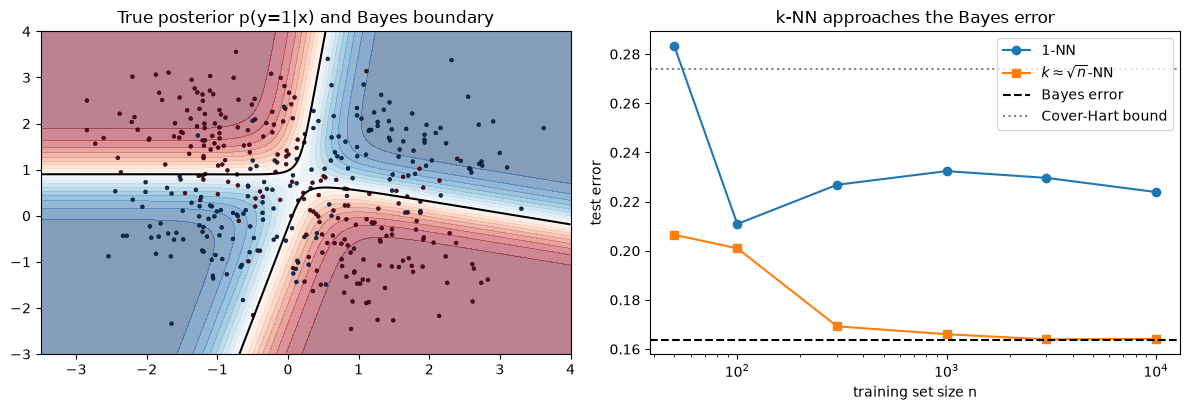

In [10]:
# Two classes, each a mixture of two Gaussians in 2-D (known densities)
means = {0: [np.array([-1.0, 0.0]), np.array([1.5, 1.5])], 1: [np.array([1.0, -0.5]), np.array([-1.0, 1.8])]}
cov = 0.6 * np.eye(2)
prior = np.array([0.5, 0.5])

def sample(n, r):
    y = r.integers(0, 2, n)
    comp = r.integers(0, 2, n)
    mu = np.array([means[c][j] for c, j in zip(y, comp)])
    return mu + r.multivariate_normal(np.zeros(2), cov, n), y

def class_density(X, c):
    return 0.5 * sum(stats.multivariate_normal(m, cov).pdf(X) for m in means[c])

def bayes_posterior(X):
    joint = np.c_[prior[0] * class_density(X, 0), prior[1] * class_density(X, 1)]
    return joint / joint.sum(1, keepdims=True)

X_big, y_big = sample(200000, np.random.default_rng(0))
bayes_err = np.mean(1 - bayes_posterior(X_big).max(1))      # E[1 - max posterior]
print(f"Bayes error R* (Monte Carlo) = {bayes_err:.4f};  Cover-Hart bound 2R*(1-R*) = {2*bayes_err*(1-bayes_err):.4f}")

X_test_b, y_test_b = X_big[:20000], y_big[:20000]
ns = [50, 100, 300, 1000, 3000, 10000]
errs = {1: [], "sqrt": []}
for n in ns:
    Xs, ys = sample(n, np.random.default_rng(n))
    errs[1].append(1 - KNeighborsClassifier(1).fit(Xs, ys).score(X_test_b, y_test_b))
    errs["sqrt"].append(1 - KNeighborsClassifier(int(np.sqrt(n)) | 1).fit(Xs, ys).score(X_test_b, y_test_b))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
x0b, x1b = np.meshgrid(np.linspace(-3.5, 4, 200), np.linspace(-3, 4, 200))
Pb = bayes_posterior(np.c_[x0b.ravel(), x1b.ravel()])[:, 1].reshape(x0b.shape)
ax[0].contourf(x0b, x1b, Pb, levels=20, cmap="RdBu_r", alpha=0.5)
ax[0].contour(x0b, x1b, Pb, levels=[0.5], colors="k")
ax[0].scatter(X_big[:400, 0], X_big[:400, 1], c=y_big[:400], cmap="RdBu_r", s=8, edgecolor="k", lw=0.3)
ax[0].set_title("True posterior p(y=1|x) and Bayes boundary")
ax[1].semilogx(ns, errs[1], "o-", label="1-NN"); ax[1].semilogx(ns, errs["sqrt"], "s-", label=r"$k\approx\sqrt{n}$-NN")
ax[1].axhline(bayes_err, c="k", ls="--", label="Bayes error")
ax[1].axhline(2 * bayes_err * (1 - bayes_err), c="gray", ls=":", label="Cover-Hart bound")
ax[1].set_xlabel("training set size n"); ax[1].set_ylabel("test error"); ax[1].legend(); ax[1].set_title("k-NN approaches the Bayes error")
plt.tight_layout(); plt.show()

## 8. Generative vs discriminative classifiers

The Bayes classifier needs $p(y\mid\mathbf{x})$. There are two routes:

| | **Discriminative** | **Generative** |
|---|---|---|
| models | $p(y\mid\mathbf{x})$ directly (or just a decision function) | the joint $p(\mathbf{x}, y) = p(\mathbf{x}\mid y)\,p(y)$ |
| examples | logistic regression, SVM, neural nets, $k$-NN | naive Bayes, LDA/QDA, Gaussian mixtures, HMMs |
| prediction | $\arg\max_c p(c\mid\mathbf{x})$ | Bayes' rule: $p(c\mid\mathbf{x}) \propto p(\mathbf{x}\mid c)\pi_c$ |
| fitting | iterative optimization of conditional likelihood | often closed form (class-wise MLE: counts, means, covariances) |
| strengths | fewer assumptions, usually lower asymptotic error | handles missing features, can sample $\mathbf{x}$, uses unlabeled data, needs less data if the model is right |

**Ng & Jordan (2002)**: comparing naive Bayes with logistic regression (its discriminative counterpart), the generative model approaches its (higher) asymptotic error with $O(\log d)$ samples, while logistic regression needs $O(d)$ samples to reach its (lower) asymptotic error. So generative models often win on **small** data, discriminative ones on **large** data. We will test this at the end of Section 9.

Many generative models induce **linear** log-odds: with Gaussian class-conditionals and shared covariance, $\log\frac{p(1\mid\mathbf{x})}{p(0\mid\mathbf{x})}$ is affine in $\mathbf{x}$ — exactly the logistic regression form (Lecture 03), but with parameters fitted differently.

## 9. Gaussian naive Bayes

**The naive Bayes assumption**: features are **conditionally independent given the class**,

$$
p(\mathbf{x}\mid y=c) = \prod_{j=1}^d p(x_j\mid y=c).
$$

This replaces one $d$-dimensional density estimate per class by $d$ one-dimensional ones — the number of parameters grows linearly in $d$, which is what makes NB work in very high dimensions (text!).

**Gaussian NB** takes $p(x_j\mid y=c) = \mathcal{N}(x_j;\ \mu_{cj}, \sigma^2_{cj})$.

**MLE derivation.** The log-likelihood of the training data factorizes:

$$
\log L = \sum_i \log\pi_{y_i} + \sum_i\sum_j \log\mathcal{N}(x_{ij};\mu_{y_i j},\sigma^2_{y_i j}).
$$

- Maximizing $\sum_i \log\pi_{y_i}$ subject to $\sum_c\pi_c = 1$ (Lagrange multiplier) gives $\hat\pi_c = n_c/n$.
- For each $(c,j)$, the terms involving $\mu_{cj},\sigma^2_{cj}$ are a univariate Gaussian log-likelihood of the samples in class $c$; setting derivatives to zero:

$$
\hat\mu_{cj} = \frac{1}{n_c}\sum_{i:y_i=c} x_{ij},
\qquad
\hat\sigma^2_{cj} = \frac{1}{n_c}\sum_{i:y_i=c}(x_{ij}-\hat\mu_{cj})^2 .
$$

**Prediction** in log space (to avoid underflow from products of many small densities):

$$
\log p(c\mid\mathbf{x}) = \log\hat\pi_c - \sum_j\Big[\tfrac12\log(2\pi\hat\sigma^2_{cj}) + \frac{(x_j-\hat\mu_{cj})^2}{2\hat\sigma^2_{cj}}\Big] - \log Z(\mathbf{x}),
$$

with the normalizer $\log Z = \operatorname{logsumexp}_c(\cdot)$. Because the variances differ per class, the decision boundary is **quadratic** (axis-aligned). A small **variance smoothing** $\epsilon \cdot \max_j \operatorname{Var}(x_j)$ is added for numerical safety (sklearn: `var_smoothing=1e-9`).

**Why it works despite the naive assumption** (Domingos & Pazzani, 1997): classification only needs the argmax to be right, not the probabilities; NB's probabilities are however typically **over-confident** (Lecture 03, calibration).

In [11]:
class GaussianNBScratch(ClassifierMixin, BaseEstimator):
    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        eps = self.var_smoothing * X.var(axis=0).max()
        self.theta_ = np.array([X[y == c].mean(0) for c in self.classes_])          # (C, d) means
        self.var_ = np.array([X[y == c].var(0) for c in self.classes_]) + eps       # (C, d) MLE variances
        self.log_prior_ = np.log(np.array([np.mean(y == c) for c in self.classes_]))
        return self

    def joint_log_likelihood(self, X):
        # log pi_c + sum_j log N(x_j; mu_cj, var_cj), for all samples and classes at once -> (n, C)
        ll = -0.5 * (np.log(2 * np.pi * self.var_)[None, :, :]
                     + (X[:, None, :] - self.theta_[None, :, :]) ** 2 / self.var_[None, :, :]).sum(2)
        return ll + self.log_prior_

    def predict_log_proba(self, X):
        jll = self.joint_log_likelihood(X)
        return jll - logsumexp(jll, axis=1, keepdims=True)

    def predict_proba(self, X):
        return np.exp(self.predict_log_proba(X))

    def predict(self, X):
        return self.classes_[np.argmax(self.joint_log_likelihood(X), axis=1)]

iris = load_iris()
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(iris.data, iris.target, test_size=0.4, stratify=iris.target, random_state=0)
g_ours = GaussianNBScratch().fit(Xi_tr, yi_tr)
g_sk = GaussianNB().fit(Xi_tr, yi_tr)
print("max |mean diff| :", np.abs(g_ours.theta_ - g_sk.theta_).max())
print("max |var diff|  :", np.abs(g_ours.var_ - g_sk.var_).max())
print("max |proba diff|:", np.abs(g_ours.predict_proba(Xi_te) - g_sk.predict_proba(Xi_te)).max())
print(f"iris test accuracy: scratch={np.mean(g_ours.predict(Xi_te) == yi_te):.4f}, sklearn={g_sk.score(Xi_te, yi_te):.4f}")

bc = load_breast_cancer()
cvs = StratifiedKFold(10, shuffle=True, random_state=0)
print(f"breast cancer 10-fold CV accuracy: GaussianNB={cross_val_score(GaussianNB(), bc.data, bc.target, cv=cvs).mean():.4f}")

max |mean diff| : 0.0
max |var diff|  : 0.0
max |proba diff|: 7.771561172376096e-16
iris test accuracy: scratch=0.9667, sklearn=0.9667
breast cancer 10-fold CV accuracy: GaussianNB=0.9384


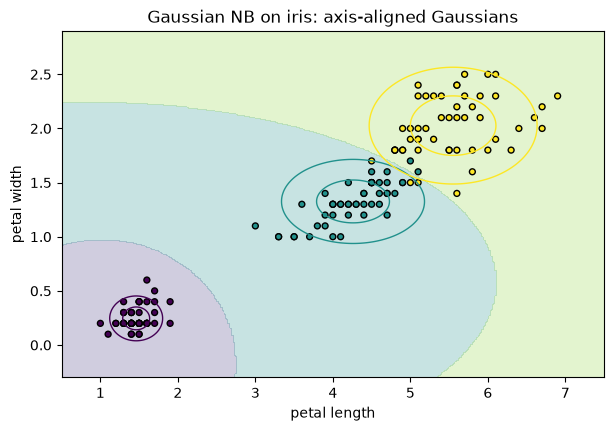

In [12]:
# Visualize the fitted class-conditional Gaussians (axis-aligned ellipses) and the quadratic boundaries
Xi2 = iris.data[:, 2:4]                                # petal length & width
g2 = GaussianNBScratch().fit(Xi2, iris.target)
x0i, x1i = np.meshgrid(np.linspace(0.5, 7.5, 300), np.linspace(-0.3, 2.9, 300))
G = np.c_[x0i.ravel(), x1i.ravel()]
pred = g2.predict(G).reshape(x0i.shape)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.contourf(x0i, x1i, pred, alpha=0.25, cmap="viridis", levels=[-0.5, 0.5, 1.5, 2.5])
for c in range(3):
    dens = np.exp(-0.5 * (((G - g2.theta_[c]) ** 2) / g2.var_[c]).sum(1)).reshape(x0i.shape)
    ax.contour(x0i, x1i, dens, levels=[0.14, 0.6], colors=[plt.cm.viridis(c / 2)], linewidths=1)
ax.scatter(Xi2[:, 0], Xi2[:, 1], c=iris.target, cmap="viridis", edgecolor="k", s=18)
ax.set_xlabel("petal length"); ax.set_ylabel("petal width"); ax.set_title("Gaussian NB on iris: axis-aligned Gaussians")
plt.show()

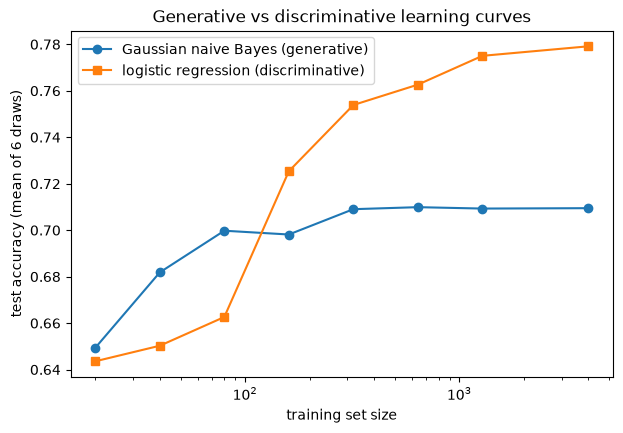

In [13]:
# Ng & Jordan: naive Bayes vs (weakly regularized) logistic regression as a function of training set size.
# Data: class-conditional Gaussians whose first 10 features share a common latent factor, so the
# naive independence assumption is violated (NB's model is misspecified; LR's linear form is correct).
d_nj = 30
shift = np.r_[np.full(10, 0.8), np.full(20, 0.3)]
def gen_nj(n, r):
    y = r.integers(0, 2, n)
    X = r.normal(size=(n, d_nj))
    X[:, :10] += r.normal(size=(n, 1))            # shared factor -> correlated features
    return X + np.outer(y - 0.5, shift), y

Xnj_te, ynj_te = gen_nj(5000, np.random.default_rng(99))
sizes = [20, 40, 80, 160, 320, 640, 1280, 4000]
acc_nb, acc_lr = [], []
for m in sizes:
    a_nb, a_lr = [], []
    for rep in range(6):
        Xs_, ys_ = gen_nj(m, np.random.default_rng(1000 * m + rep))
        a_nb.append(GaussianNB().fit(Xs_, ys_).score(Xnj_te, ynj_te))
        a_lr.append(LogisticRegression(C=100, max_iter=5000).fit(Xs_, ys_).score(Xnj_te, ynj_te))
    acc_nb.append(np.mean(a_nb)); acc_lr.append(np.mean(a_lr))
plt.semilogx(sizes, acc_nb, "o-", label="Gaussian naive Bayes (generative)")
plt.semilogx(sizes, acc_lr, "s-", label="logistic regression (discriminative)")
plt.xlabel("training set size"); plt.ylabel("test accuracy (mean of 6 draws)"); plt.legend()
plt.title("Generative vs discriminative learning curves"); plt.show()

Typically naive Bayes is competitive or better with very few samples (its few parameters are estimated quickly), while logistic regression overtakes it once $n$ is large enough to exploit its weaker assumptions — the crossover predicted by Ng & Jordan. The exact crossover point depends on how badly the independence assumption is violated.

## 10. Multinomial naive Bayes for text

**Bag-of-words.** A document is represented by its count vector $\mathbf{x}\in\mathbb{N}^V$ over a vocabulary of size $V$ ($x_j$ = number of occurrences of word $j$); word order is discarded. `CountVectorizer` builds this sparse document–term matrix.

**Model.** Given class $c$, a document of length $L=\sum_j x_j$ is a sequence of $L$ i.i.d. draws from a class-specific categorical distribution $\boldsymbol\theta_c$ over words ($\sum_j\theta_{cj}=1$):

$$
p(\mathbf{x}\mid c) = \frac{L!}{\prod_j x_j!}\prod_{j=1}^V \theta_{cj}^{x_j}
\quad\Longrightarrow\quad
\log p(c\mid\mathbf{x}) = \log\pi_c + \sum_j x_j\log\theta_{cj} + \text{const}.
$$

Note that this is **linear** in $\mathbf{x}$ — multinomial NB is a linear classifier in count space.

**MLE.** Maximizing $\sum_{i:y_i=c}\sum_j x_{ij}\log\theta_{cj}$ subject to $\sum_j\theta_{cj}=1$ with a Lagrange multiplier gives $\hat\theta_{cj} = N_{cj}/N_c$, where $N_{cj} = \sum_{i: y_i=c} x_{ij}$ is the total count of word $j$ in class $c$ and $N_c=\sum_j N_{cj}$.

**The zero-count problem.** If a word never occurs in class $c$ in training, $\hat\theta_{cj}=0$ and any test document containing it gets $\log p = -\infty$ for that class, regardless of all other evidence.

**Laplace (additive) smoothing** fixes this:

$$
\hat\theta_{cj} = \frac{N_{cj} + \alpha}{N_c + \alpha V},
$$

with $\alpha=1$ (Laplace) or $0<\alpha<1$ (Lidstone). This is the **posterior mean** of $\boldsymbol\theta_c$ under a symmetric Dirichlet$(\alpha)$ prior — or equivalently the MAP estimate under a Dirichlet$(\alpha+1)$ prior — i.e. we pretend to have seen every word $\alpha$ extra times in each class.

In [14]:
corpus = [
    ("the team won the match with a late goal", "sports"),
    ("the striker scored twice and the fans cheered", "sports"),
    ("a thrilling final saw the champions lift the trophy", "sports"),
    ("the coach praised the defense after the win", "sports"),
    ("injury forces the goalkeeper to miss the season", "sports"),
    ("the referee showed a red card in the second half", "sports"),
    ("the new phone has a faster processor and better camera", "tech"),
    ("the startup released an open source machine learning library", "tech"),
    ("software update fixes a security bug in the browser", "tech"),
    ("the laptop battery lasts longer with the new chip", "tech"),
    ("researchers trained a neural network on a large dataset", "tech"),
    ("the app crashed after the latest software release", "tech"),
    ("the central bank raised interest rates again", "finance"),
    ("stocks fell as investors worried about inflation", "finance"),
    ("the company reported record profits this quarter", "finance"),
    ("bond yields climbed after the rate decision", "finance"),
    ("the market rallied on strong earnings from banks", "finance"),
    ("investors moved money into gold amid market volatility", "finance"),
]
docs = [d for d, _ in corpus]
labels = np.array([l for _, l in corpus])
vec = CountVectorizer()                        # lowercases and tokenizes on word boundaries
Xtxt = vec.fit_transform(docs)                 # sparse (n_docs, V) count matrix
vocab = vec.get_feature_names_out()
print(f"{Xtxt.shape[0]} documents, vocabulary size V = {len(vocab)}")
print(pd.DataFrame(Xtxt[:3].toarray(), columns=vocab).loc[:, lambda d: d.sum() > 0].to_string())

18 documents, vocabulary size V = 110
   and  champions  cheered  fans  final  goal  late  lift  match  saw  scored  striker  team  the  thrilling  trophy  twice  with  won
0    0          0        0     0      0     1     1     0      1    0       0        0     1    2          0       0      0     1    1
1    1          0        1     1      0     0     0     0      0    0       1        1     0    2          0       0      1     0    0
2    0          1        0     0      1     0     0     1      0    1       0        0     0    2          1       1      0     0    0


In [15]:
class MultinomialNBScratch:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        X = np.asarray(X.todense()) if hasattr(X, "todense") else np.asarray(X)
        self.classes_ = np.unique(y)
        N_cj = np.array([X[y == c].sum(0) for c in self.classes_])               # (C, V) word counts per class
        V = X.shape[1]
        self.feature_log_prob_ = np.log((N_cj + self.alpha) / (N_cj.sum(1, keepdims=True) + self.alpha * V))
        self.class_log_prior_ = np.log(np.array([np.mean(y == c) for c in self.classes_]))
        return self

    def joint_log_likelihood(self, X):
        return X @ self.feature_log_prob_.T + self.class_log_prior_           # linear in the counts

    def predict_proba(self, X):
        jll = np.asarray(self.joint_log_likelihood(X))
        return np.exp(jll - logsumexp(jll, axis=1, keepdims=True))

    def predict(self, X):
        return self.classes_[np.argmax(np.asarray(self.joint_log_likelihood(X)), axis=1)]

mnb = MultinomialNBScratch(alpha=1.0).fit(Xtxt, labels)
mnb_sk = MultinomialNB(alpha=1.0).fit(Xtxt, labels)
print("max |log theta diff| vs sklearn:", np.abs(mnb.feature_log_prob_ - mnb_sk.feature_log_prob_).max())

test_docs = ["the fans cheered the late winner",
             "a bug in the new chip slowed the phone",
             "banks reported profits despite higher rates",
             "the team released a new app for fans"]
Xq = vec.transform(test_docs)                  # unseen words are simply ignored
P = mnb.predict_proba(Xq)
for doc, p, pred_sk in zip(test_docs, P, mnb_sk.predict(Xq)):
    print(f"{doc:<45s} -> " + "  ".join(f"{c}={pc:.2f}" for c, pc in zip(mnb.classes_, p)) + f"   (sklearn: {pred_sk})")

max |log theta diff| vs sklearn: 8.881784197001252e-16
the fans cheered the late winner              -> finance=0.02  sports=0.94  tech=0.04   (sklearn: sports)
a bug in the new chip slowed the phone        -> finance=0.01  sports=0.12  tech=0.87   (sklearn: tech)
banks reported profits despite higher rates   -> finance=0.90  sports=0.05  tech=0.05   (sklearn: finance)
the team released a new app for fans          -> finance=0.04  sports=0.36  tech=0.60   (sklearn: tech)


In [16]:
# Why smoothing matters: alpha -> 0 gives -inf log-probabilities for words unseen in a class.
q = vec.transform(["the striker scored a goal but stocks fell"])
for alpha in [1e-10, 0.1, 1.0, 5.0]:
    m = MultinomialNBScratch(alpha=alpha).fit(Xtxt, labels)
    jll = np.asarray(m.joint_log_likelihood(q))[0]
    print(f"alpha={alpha:<6g} joint log-lik: " + "  ".join(f"{c}={v:9.2f}" for c, v in zip(m.classes_, jll)))

# Most indicative words per class: log theta_cj - mean over classes
lp = mnb.feature_log_prob_
for ci, c in enumerate(mnb.classes_):
    score = lp[ci] - lp.mean(0)
    print(f"{c:>8s}: " + ", ".join(vocab[np.argsort(-score)[:6]]))

alpha=1e-10  joint log-lik: finance=   -91.50  sports=   -67.94  tech=  -137.75
alpha=0.1    joint log-lik: finance=   -30.45  sports=   -27.41  tech=   -35.32
alpha=1      joint log-lik: finance=   -28.32  sports=   -26.79  tech=   -29.47
alpha=5      joint log-lik: finance=   -28.81  sports=   -27.99  tech=   -28.95
 finance: market, investors, about, again, banks, bond
  sports: the, coach, defense, cheered, champions, card
    tech: software, new, app, an, browser, bug


With $\alpha\approx 0$, a single word that never appeared in a class ("stocks" in sports, "striker" in finance) drives that class's log-likelihood to about $-23$ per word ($\log 10^{-10}$), overruling all other evidence; with $\alpha = 1$ the evidence is weighed smoothly. In practice $\alpha$ is a hyperparameter tuned by CV, and multinomial NB on TF-IDF or counts remains a strong, fast baseline for text classification (Rennie et al., 2003; Wang & Manning, 2012).

## 11. LDA and QDA

Model each class-conditional as a full multivariate Gaussian, $p(\mathbf{x}\mid c) = \mathcal{N}(\mathbf{x};\boldsymbol\mu_c,\Sigma_c)$. The log-posterior (up to a constant) is the **discriminant function**

$$
\delta_c(\mathbf{x}) = -\tfrac12\log|\Sigma_c| - \tfrac12(\mathbf{x}-\boldsymbol\mu_c)^\top\Sigma_c^{-1}(\mathbf{x}-\boldsymbol\mu_c) + \log\pi_c ,
\qquad \hat y = \arg\max_c \delta_c(\mathbf{x}).
$$

**QDA** (quadratic discriminant analysis): separate $\Sigma_c$ per class. MLE: $\hat{\boldsymbol\mu}_c$ = class mean, $\hat\Sigma_c = \frac{1}{n_c}\sum_{i:y_i=c}(\mathbf{x}_i-\hat{\boldsymbol\mu}_c)(\mathbf{x}_i-\hat{\boldsymbol\mu}_c)^\top$ (the unbiased version divides by $n_c-1$; the difference matters only for small $n_c$). The boundaries $\{\delta_c = \delta_{c'}\}$ are **quadrics**. Parameters: $K\big(d + d(d+1)/2\big)$ — expensive in high $d$.

**LDA** (linear discriminant analysis): shared covariance $\Sigma_c = \Sigma$, estimated (MLE) by the pooled within-class covariance $\hat\Sigma = \frac{1}{n}\sum_c\sum_{i:y_i=c}(\mathbf{x}_i-\hat{\boldsymbol\mu}_c)(\mathbf{x}_i-\hat{\boldsymbol\mu}_c)^\top$ (or $\frac{1}{n-K}$ for the unbiased version). Then the quadratic term $\mathbf{x}^\top\Sigma^{-1}\mathbf{x}$ is common to all classes and cancels, leaving a **linear** discriminant:

$$
\delta_c(\mathbf{x}) = \mathbf{x}^\top\Sigma^{-1}\boldsymbol\mu_c - \tfrac12\boldsymbol\mu_c^\top\Sigma^{-1}\boldsymbol\mu_c + \log\pi_c .
$$

For two classes, the log-odds is $\mathbf{w}^\top\mathbf{x}+b$ with $\mathbf{w} = \Sigma^{-1}(\boldsymbol\mu_1-\boldsymbol\mu_0)$ — the same functional form as logistic regression, but estimated generatively (more efficient if the Gaussian assumption holds, less robust if it does not). $\mathbf{w}$ is also Fisher's discriminant direction.

**Relations**: Gaussian NB = QDA with **diagonal** $\Sigma_c$. **Regularized discriminant analysis** shrinks $\hat\Sigma_c$ toward $\hat\Sigma$ and/or toward $\sigma^2 I$ (Friedman, 1989), e.g. `LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")` uses Ledoit–Wolf shrinkage.

In [17]:
class GaussianDiscriminant(ClassifierMixin, BaseEstimator):
    # LDA (shared covariance) or QDA (per-class covariance), fitted by maximum likelihood.
    def __init__(self, kind="lda", reg=0.0):
        self.kind, self.reg = kind, reg

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n, d = X.shape; K = len(self.classes_)
        self.means_ = np.array([X[y == c].mean(0) for c in self.classes_])
        self.log_prior_ = np.log(np.array([np.mean(y == c) for c in self.classes_]))
        scatters = [(X[y == c] - m).T @ (X[y == c] - m) for c, m in zip(self.classes_, self.means_)]
        if self.kind == "lda":
            S = sum(scatters) / n + self.reg * np.eye(d)                # pooled within-class covariance (MLE)
            self.covs_ = [S] * K
        else:
            self.covs_ = [Sc / np.sum(y == c) + self.reg * np.eye(d) for Sc, c in zip(scatters, self.classes_)]  # MLE
        # Precompute inverse and log-determinant via Cholesky for stability
        self.chol_ = [np.linalg.cholesky(S) for S in self.covs_]
        self.logdet_ = [2 * np.log(np.diag(L)).sum() for L in self.chol_]
        return self

    def decision_function(self, X):
        out = []
        for L, ld, mu, lp in zip(self.chol_, self.logdet_, self.means_, self.log_prior_):
            Z = np.linalg.solve(L, (X - mu).T)                         # L^{-1}(x - mu)  -> Mahalanobis
            out.append(-0.5 * ld - 0.5 * (Z ** 2).sum(0) + lp)
        return np.array(out).T

    def predict_proba(self, X):
        D = self.decision_function(X)
        return np.exp(D - logsumexp(D, axis=1, keepdims=True))

    def predict(self, X):
        return self.classes_[np.argmax(self.decision_function(X), axis=1)]

wine_X, wine_y = wine.data, wine.target
Xw_tr, Xw_te, yw_tr, yw_te = train_test_split(wine_X, wine_y, test_size=0.4, stratify=wine_y, random_state=0)
for kind, SK in [("lda", LinearDiscriminantAnalysis()), ("qda", QuadraticDiscriminantAnalysis())]:
    ours = GaussianDiscriminant(kind).fit(Xw_tr, yw_tr); sk = SK.fit(Xw_tr, yw_tr)
    print(f"{kind.upper()}: scratch acc={np.mean(ours.predict(Xw_te) == yw_te):.4f}  sklearn acc={sk.score(Xw_te, yw_te):.4f}  "
          f"max |proba diff|={np.abs(ours.predict_proba(Xw_te) - sk.predict_proba(Xw_te)).max():.2e}")

LDA: scratch acc=0.9861  sklearn acc=0.9861  max |proba diff|=1.35e-14
QDA: scratch acc=0.9583  sklearn acc=0.9583  max |proba diff|=3.19e-14


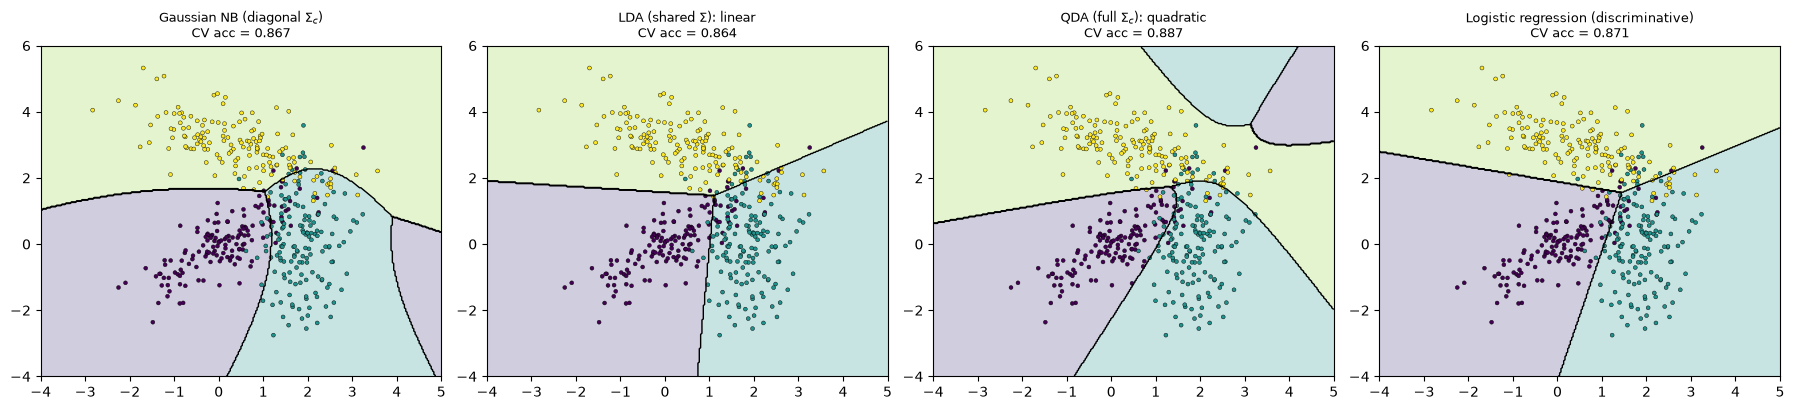

In [18]:
# Boundary comparison on 2-D synthetic data where the classes have different covariances
r2 = np.random.default_rng(7)
n_per = 150
Xa = r2.multivariate_normal([0, 0], [[1.0, 0.8], [0.8, 1.0]], n_per)
Xb2 = r2.multivariate_normal([2.0, 0.0], [[0.3, 0.0], [0.0, 2.0]], n_per)
Xc = r2.multivariate_normal([0.5, 3.0], [[1.5, -0.6], [-0.6, 0.6]], n_per)
X3 = np.vstack([Xa, Xb2, Xc]); y3 = np.repeat([0, 1, 2], n_per)

x0g, x1g = np.meshgrid(np.linspace(-4, 5, 300), np.linspace(-4, 6, 300))
G = np.c_[x0g.ravel(), x1g.ravel()]
models = [("Gaussian NB (diagonal $\\Sigma_c$)", GaussianNBScratch()),
          ("LDA (shared $\\Sigma$): linear", GaussianDiscriminant("lda")),
          ("QDA (full $\\Sigma_c$): quadratic", GaussianDiscriminant("qda")),
          ("Logistic regression (discriminative)", LogisticRegression())]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, (name, mdl) in zip(axes, models):
    mdl.fit(X3, y3)
    Z = mdl.predict(G).reshape(x0g.shape)
    ax.contourf(x0g, x1g, Z, alpha=0.25, levels=[-0.5, 0.5, 1.5, 2.5], cmap="viridis")
    ax.contour(x0g, x1g, Z, levels=[0.5, 1.5], colors="k", linewidths=1)
    ax.scatter(X3[:, 0], X3[:, 1], c=y3, cmap="viridis", s=8, edgecolor="k", lw=0.3)
    # our scratch classes inherit BaseEstimator/ClassifierMixin, so they work with cross_val_score
    cvacc = cross_val_score(mdl, X3, y3, cv=StratifiedKFold(5, shuffle=True, random_state=0)).mean()
    ax.set_title(f"{name}\nCV acc = {cvacc:.3f}", fontsize=9)
plt.tight_layout(); plt.show()

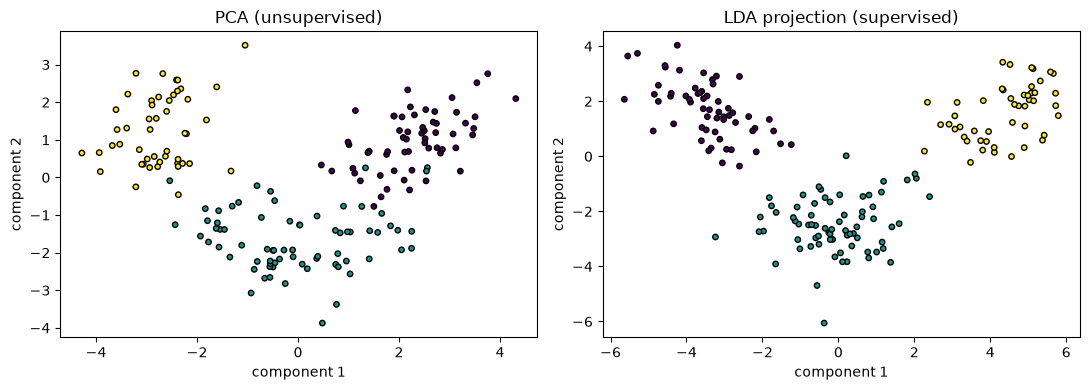

                  iris   wine  breast cancer  digits
5-NN (scaled)    0.953  0.961          0.965   0.977
GaussianNB       0.960  0.972          0.939   0.851
LDA              0.980  0.994          0.954   0.951
QDA (reg=0.1)    0.960  0.977          0.956   0.979
LogReg (scaled)  0.960  0.983          0.979   0.969


In [19]:
# LDA as dimensionality reduction: project onto the K-1 = 2 discriminant directions (Fisher)
lda = LinearDiscriminantAnalysis(n_components=2).fit(wine_X, wine_y)
Zw = lda.transform(wine_X)
from sklearn.decomposition import PCA
Zp = PCA(2).fit_transform(StandardScaler().fit_transform(wine_X))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(Zp[:, 0], Zp[:, 1], c=wine_y, cmap="viridis", s=15, edgecolor="k"); ax[0].set_title("PCA (unsupervised)")
ax[1].scatter(Zw[:, 0], Zw[:, 1], c=wine_y, cmap="viridis", s=15, edgecolor="k"); ax[1].set_title("LDA projection (supervised)")
for a in ax: a.set_xlabel("component 1"); a.set_ylabel("component 2")
plt.tight_layout(); plt.show()

# Summary comparison on several datasets (5-fold CV accuracy)
cv5 = StratifiedKFold(5, shuffle=True, random_state=0)
data_sets = {"iris": load_iris(return_X_y=True), "wine": load_wine(return_X_y=True),
             "breast cancer": load_breast_cancer(return_X_y=True), "digits": load_digits(return_X_y=True)}
clfs = {"5-NN (scaled)": make_pipeline(StandardScaler(), KNeighborsClassifier(5)),
        "GaussianNB": GaussianNB(),
        "LDA": LinearDiscriminantAnalysis(),
        "QDA (reg=0.1)": QuadraticDiscriminantAnalysis(reg_param=0.1),
        "LogReg (scaled)": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))}
table = pd.DataFrame({dn: {cn: cross_val_score(c, Xs, ys, cv=cv5, n_jobs=-1).mean() for cn, c in clfs.items()}
                      for dn, (Xs, ys) in data_sets.items()})
print(table.round(3).to_string())

## 12. Pitfalls & practical tips

- **$k$-NN**: always scale features (in a pipeline); tune $k$ (and the metric / weighting) by CV; remove irrelevant features or learn a metric; beware of prediction cost $O(nd)$ per query and memory $O(nd)$; use tree or approximate indexes for large $n$ and low-to-moderate $d$.
- **Ties** in $k$-NN votes and in distances are resolved arbitrarily; use odd $k$ for binary problems or distance weighting.
- **Class imbalance**: the majority class dominates neighbourhoods; consider distance weighting, class-balanced voting, or adjusting thresholds on `predict_proba`.
- **Naive Bayes probabilities are over-confident** when features are correlated (evidence is double-counted); use them for ranking or calibrate them.
- **Zero counts / zero variances**: always smooth (Laplace $\alpha$, `var_smoothing`); work in log space with `logsumexp`.
- **Pick the right NB event model**: Gaussian for continuous features, multinomial for counts, Bernoulli for binary presence/absence, complement NB for imbalanced text.
- **QDA** needs $n_c \gg d$ per class (each $\hat\Sigma_c$ must be invertible); otherwise regularize (`reg_param`) or use LDA with shrinkage. LDA is surprisingly robust even when covariances differ moderately.
- Generative models are cheap and good with **little data**; discriminative models usually win with **lots of data** — try both.

## 13. Exercises

**Exercise 1 (math).** Show that for two classes with Gaussian class-conditionals and a shared covariance, the posterior is $p(y=1\mid\mathbf{x}) = \sigma(\mathbf{w}^\top\mathbf{x}+b)$ and give $\mathbf{w}$ and $b$ in terms of $\boldsymbol\mu_0,\boldsymbol\mu_1,\Sigma,\pi_0,\pi_1$. What changes when $\Sigma_0\neq\Sigma_1$?

**Exercise 2 (math).** Derive the Laplace-smoothed estimate $\hat\theta_{cj} = (N_{cj}+\alpha)/(N_c+\alpha V)$ as the posterior mean of $\boldsymbol\theta_c$ under a symmetric Dirichlet$(\alpha)$ prior. (Hint: the Dirichlet is conjugate to the multinomial.)

**Exercise 3 (coding).** Extend `KNNClassifierScratch` to $k$-NN **regression** with uniform and distance weights, and compare its CV mean squared error with `KNeighborsRegressor` on `load_diabetes` for $k\in\{1,\dots,50\}$. Plot the validation curve.

**Exercise 4 (coding).** Implement a simple KD-tree (recursive median split, cycling through coordinates) with a 1-NN query that backtracks with pruning. Count the number of distance evaluations per query for $d\in\{2, 5, 10, 20\}$ with $n=10{,}000$ uniform points and compare with brute force ($n$ evaluations).

**Exercise 5 (coding).** Implement **Bernoulli naive Bayes** (binary word presence, including the $(1-\theta_{cj})$ terms for absent words) and compare it with multinomial NB on the toy corpus using leave-one-out CV.

**Exercise 6 (analysis).** Using the mixture-of-Gaussians data from Section 7, estimate the test error of Gaussian NB, LDA, QDA and $k$-NN (CV-tuned $k$) for $n\in\{50, 200, 1000, 5000\}$ and compare with the Bayes error. Which models are consistent for this distribution and why?

In [20]:
# Exercise 3 starter
class KNNRegressorScratch:
    def __init__(self, k=5, weights="uniform"):
        self.k, self.weights = k, weights
    def fit(self, X, y):
        # TODO: store the training data
        return self
    def predict(self, Q):
        # TODO: reuse pairwise_sq_dists + argpartition; average (weighted) neighbour targets
        return None

# Exercise 4 starter
def build_kdtree(X, idx=None, depth=0, leaf_size=10):
    # TODO: return a nested dict {"axis", "split", "left", "right"} or a leaf {"idx": ...}
    return None

def kdtree_query_1nn(tree, X, q):
    # TODO: descend, then backtrack; prune a branch if |q[axis] - split| >= best distance.
    return None

# Exercise 5 starter
class BernoulliNBScratch:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
    def fit(self, X, y):
        # TODO: theta_cj = (#docs in c containing word j + alpha) / (n_c + 2 alpha)
        return self
    def predict(self, X):
        # TODO: sum_j [x_j log theta_cj + (1 - x_j) log(1 - theta_cj)] + log pi_c
        return None

print("Exercise stubs defined.")

Exercise stubs defined.


## 14. Summary

- **$k$-NN** stores the data and votes among the $k$ closest points; $k$ controls the bias–variance trade-off (effective parameters $\approx n/k$), and 1-NN's asymptotic error is at most twice the Bayes error.
- Distances must be meaningful: **scale features**, choose the metric, and drop irrelevant features.
- The **curse of dimensionality** — vanishing relative contrast and non-local neighbourhoods — undermines local methods and space-partitioning indexes (KD-trees are $O(\log n)$ per query only in low $d$).
- The **Bayes classifier** $\arg\max_c p(\mathbf{x}\mid c)\pi_c$ is optimal; generative classifiers estimate its ingredients, discriminative ones estimate $p(y\mid\mathbf{x})$ directly.
- **Naive Bayes** assumes conditional independence: Gaussian NB for continuous data, multinomial NB with **Laplace smoothing** for text; fitting is closed-form counting, and prediction should be done in log space.
- **LDA** (shared covariance) gives linear boundaries and doubles as supervised dimensionality reduction; **QDA** (per-class covariance) gives quadratic boundaries but needs more data; Gaussian NB is QDA with diagonal covariances.

## Further reading

- James et al. — *ISLP*, §2.2.3 ($k$-NN), §4.4 (LDA, QDA, naive Bayes), §4.5 (comparison).
- Hastie, Tibshirani, Friedman — *ESL*, §2.3–2.5 (nearest neighbours, curse of dimensionality), §4.3 (LDA/QDA/RDA), §6.6.3 (naive Bayes), Ch. 13 (prototype methods and nearest neighbours).
- Bishop — *PRML*, §2.5.2 (nearest-neighbour methods), §4.2 (probabilistic generative models).
- Murphy — *Probabilistic Machine Learning: An Introduction*, §9.1–9.3 (Gaussian discriminant analysis, naive Bayes), §16.1 ($k$-NN).
- Géron — *Hands-On Machine Learning*, Ch. 3 and appendix on SVM/kNN usage.
- Cover & Hart (1967), "Nearest neighbor pattern classification", *IEEE Trans. Information Theory*.
- Friedman, Bentley & Finkel (1977), "An algorithm for finding best matches in logarithmic expected time", *ACM TOMS*.
- Beyer, Goldstein, Ramakrishnan & Shaft (1999), "When is 'nearest neighbor' meaningful?", *ICDT*.
- Domingos & Pazzani (1997), "On the optimality of the simple Bayesian classifier under zero-one loss", *Machine Learning*.
- Ng & Jordan (2002), "On discriminative vs. generative classifiers: a comparison of logistic regression and naive Bayes", *NeurIPS*.
- Rennie, Shih, Teevan & Karger (2003), "Tackling the poor assumptions of naive Bayes text classifiers", *ICML*.